New: Testing Data augmentation pipeline for MP-20

In [62]:
import __init__
import pandas as pd
df = pd.read_parquet('HF-databases/mp_20/mp_20_db_clean.parquet')

df

,Database,Material ID,Reduced Formula,CIF,Split
0,mp_20,mp-1221227,Na3MnCoNiO6,data_[Na3Mn1Co1Ni1O6]\nloop_\n _atom_type_symb...,train
1,mp_20,mp-974729,Nd(Al2Cu)4,data_[Nd1Al8Cu4]\nloop_\n _atom_type_symbol\n ...,train
2,mp_20,mp-1185360,LiMnIr2,data_[Li1Mn1Ir2]\nloop_\n _atom_type_symbol\n ...,train
3,mp_20,mp-1188861,LiCSN,data_[Li4C4S4N4]\nloop_\n _atom_type_symbol\n ...,train
4,mp_20,mp-677272,La2EuS4,data_[La4Eu2S8]\nloop_\n _atom_type_symbol\n _...,train
...,...,...,...,...,...
45224,mp_20,mp-21084,In6Ga2PtO8,data_[In6Ga2Pt1O8]\nloop_\n _atom_type_symbol\...,test
45225,mp_20,mp-571486,CuSe,data_[Cu6Se6]\nloop_\n _atom_type_symbol\n _at...,test
45226,mp_20,mp-14410,Tl6TeO12,data_[Tl6Te1O12]\nloop_\n _atom_type_symbol\n ...,test
45227,mp_20,mp-1079192,Sr2GdRuO6,data_[Sr2Gd1Ru1O6]\nloop_\n _atom_type_symbol\...,test


In [84]:
!python _utils/_preprocessing/_cleaning.py \
    --input_parquet '/home/cyprien/Data_Gen/mp-20-data/all_data.parquet' \
    --output_parquet 'HF-databases/mp_20/mp_20_clean.parquet' \
    --num_workers 24

Loading data from /home/cyprien/Data_Gen/mp-20-data/all_data.parquet as Parquet with zstd compression...

Processing 45229 CIFs with 24 workers

 40%|█████████████▉                     | 18000/45229 [01:02<00:16, 1605.74it/s]spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib: ssm_get_exact_positions failed.
spglib: get_bravais_exact_positions_and_lattice failed.
spglib:

In [88]:
!python _utils/_preprocessing/_cleaning_all.py \
    --input_parquet '/home/cyprien/Data_Gen/mp-20-data/all_data.parquet' \
    --output_parquet 'HF-databases/mp_20/mp_20_db_xclean_all.parquet' \
    --num_workers 24 \
    --context_length 1024 \
    --xtra_augment

Loading data from /home/cyprien/Data_Gen/mp-20-data/all_data.parquet as Parquet with zstd compression...

Processing 45229 CIFs with 24 workers

Context length: 1024 (token counting enabled, variants above threshold will be blanked)

Building augmentation variants for train rows

Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is

In [81]:
!python _utils/_preprocessing/_cleaning.py \
    --input_parquet '/home/cyprien/Data_Gen/mp-20-data/all_data.parquet' \
    --output_parquet 'HF-databases/mp_20/mp_20_db_xclean_sc.parquet' \
    --num_workers 24 \
    --context_length 1024 \
    --xtra_augment

Loading data from /home/cyprien/Data_Gen/mp-20-data/all_data.parquet as Parquet with zstd compression...

Processing 45229 CIFs with 24 workers

Context length: 1024 (token counting enabled, variants above threshold will be blanked)

Building augmentation variants for train rows

Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is consistent.
Tokenizer validation passed: token vocabulary is

In [89]:
# df = pd.read_parquet('HF-databases/mp_20/mp_20_clean.parquet')
# df = pd.read_parquet('HF-databases/mp_20/mp_20_db_xclean_sc.parquet')
df = pd.read_parquet('HF-databases/mp_20/mp_20_db_xclean_all.parquet')
 
# count how many rows have a non-empty 'CIF_CONVENTIONAL' column
df


,Material ID,Reduced_Formula,CIF,Split,CIF_NIGGLI,CIF_PRIMITIVE,CIF_SUPERCELL,supercell_params,token_count_by_cif_variant
0,mp-1221227,Na3MnCoNiO6,data_[Na6Mn2Co2Ni2O12]\nloop_\n _atom_type_sym...,train,,data_[Na3Mn1Co1Ni1O6]\nloop_\n _atom_type_symb...,,[],"[714, 0, 712, 0]"
1,mp-974729,Nd(Al2Cu)4,data_[Nd2Al16Cu8]\nloop_\n _atom_type_symbol\n...,train,,data_[Nd1Al8Cu4]\nloop_\n _atom_type_symbol\n ...,,[],"[406, 0, 685, 0]"
2,mp-1185360,LiMnIr2,data_[Li4Mn4Ir8]\nloop_\n _atom_type_symbol\n ...,train,data_[Li4Mn4Ir8]\nloop_\n _atom_type_symbol\n ...,data_[Li1Mn1Ir2]\nloop_\n _atom_type_symbol\n ...,,[],"[370, 771, 398, 0]"
3,mp-1188861,LiCSN,data_[Li4C4S4N4]\nloop_\n _atom_type_symbol\n ...,train,data_[Li4C4S4N4]\nloop_\n _atom_type_symbol\n ...,,,[],"[430, 801, 0, 0]"
4,mp-677272,La2EuS4,data_[La8Eu4S16]\nloop_\n _atom_type_symbol\n ...,train,,data_[La4Eu2S8]\nloop_\n _atom_type_symbol\n _...,,[],"[374, 0, 717, 0]"
...,...,...,...,...,...,...,...,...,...
45224,mp-21084,In6Ga2PtO8,data_[In24Ga8Pt4O32]\nloop_\n _atom_type_symbo...,test,,,,[],"[443, 0, 0, 0]"
45225,mp-571486,CuSe,data_[Cu12Se12]\nloop_\n _atom_type_symbol\n _...,test,,,,[],"[375, 0, 0, 0]"
45226,mp-14410,Tl6TeO12,data_[Tl18Te3O36]\nloop_\n _atom_type_symbol\n...,test,,,,[],"[411, 0, 0, 0]"
45227,mp-1079192,Sr2GdRuO6,data_[Sr4Gd2Ru2O12]\nloop_\n _atom_type_symbol...,test,,,,[],"[464, 0, 0, 0]"


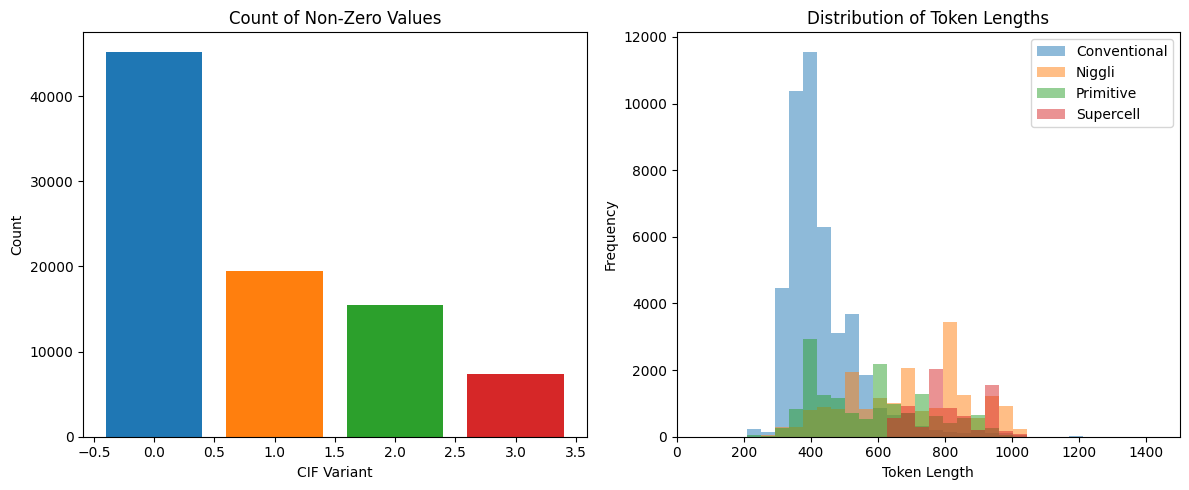

In [52]:
import matplotlib.pyplot as plt
import numpy as np

tc = df['token_count_by_cif_variant'].astype(str).str.strip('[]').str.split(expand=True).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# first index should be conventional, then niggli, then primitive, then supercell
# rename in legend

non_zero_counts = (tc > 0).sum()
axes[0].bar(non_zero_counts.index, non_zero_counts.values, color=plt.cm.tab10.colors[:len(tc.columns)])
axes[0].set_title('Count of Non-Zero Values')
axes[0].set_xlabel('CIF Variant')
axes[0].set_ylabel('Count')

bins = np.linspace(0, 2048, 50)

labels = ['Conventional', 'Niggli', 'Primitive', 'Supercell']
for i in tc.columns:
    # only for non-zero values
    non_zero_values = tc[tc[i] > 0][i]
    axes[1].hist(non_zero_values, bins=bins, alpha=0.5, label=labels[i])

axes[1].set_xlim(0, 1500)
axes[1].set_title('Distribution of Token Lengths')
axes[1].set_xlabel('Token Length')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()


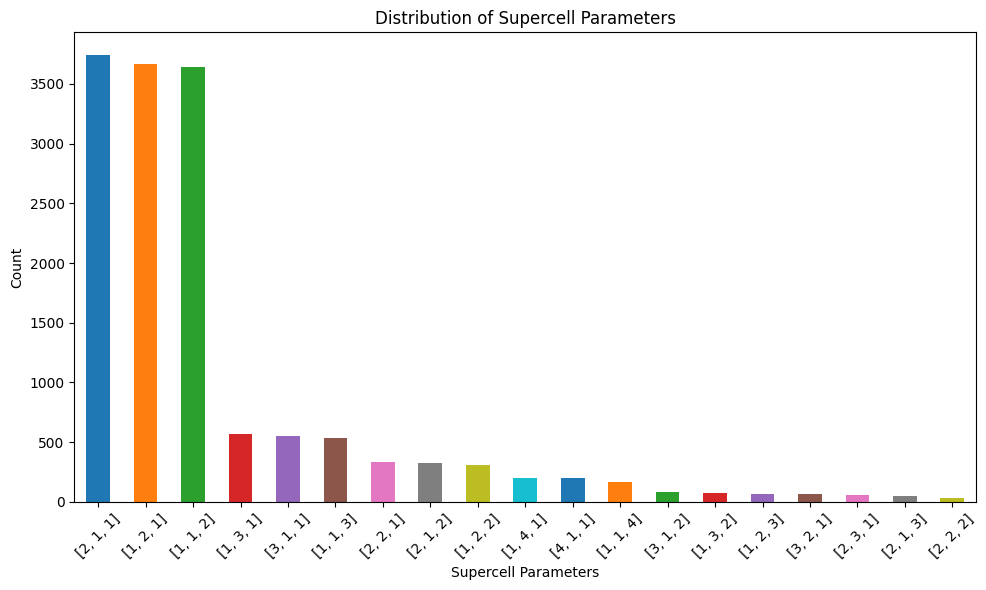

In [74]:
vc = df['supercell_params'].explode().dropna().loc[lambda x: x.map(len) > 0].map(tuple).value_counts().sort_index()

# rank from most common to least common
vc = vc.sort_values(ascending=False)

vc.set_axis(vc.index.map(list).map(str)).plot.bar(figsize=(10, 6), rot=45, title='Distribution of Supercell Parameters', xlabel='Supercell Parameters', ylabel='Count', color=plt.cm.tab10.colors[:len(vc)])
plt.tight_layout()

In [92]:
!python _utils/_preprocessing/_save_dataset_to_HF.py \
    --input_parquet HF-databases/mp_20/mp_20_clean.parquet \
    --output_parquet HF-databases/mp_20/mp_20.parquet \
    --save_hub

Loading Hugging Face API key from API_keys.jsonc
Loading data from HF-databases/mp_20/mp_20_clean.parquet as Parquet with zstd compression
Splitting dataset according to the 'Split' column
README.md: 100%|███████████████████████████████| 616/616 [00:00<00:00, 2.10MB/s]
Dataset saved to Hugging Face Hub as c-bone/mp_20


In [94]:
!torchrun --nproc_per_node=2 _train.py --config '_config_files/training/unconditional/_xtra_augment/mp_20-Xaug-all.jsonc'

W0401 17:42:27.549000 1625352 site-packages/torch/distributed/run.py:793] 
W0401 17:42:27.549000 1625352 site-packages/torch/distributed/run.py:793] *****************************************
W0401 17:42:27.549000 1625352 site-packages/torch/distributed/run.py:793] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0401 17:42:27.549000 1625352 site-packages/torch/distributed/run.py:793] *****************************************

Process/rank 1 (PID 1629536) acquired port 33252
Arguments:
	config: _config_files/training/unconditional/_xtra_augment/mp_20-Xaug-all.jsonc
	dataset_HF: c-bone/mp_20_Xaug_all
	pretrained_tokenizer_dir: HF-cif-tokenizer
	context_length: 1024
	remove_CIFs_above_context: True
	remove_CIFs_with_unk: False
	condition_columns: None
	n_prefix_tokens: None
	n_hidden_cond: None
	cond_dropout: None
	share_layers: 

In [95]:
!torchrun --nproc_per_node=2 _train.py --config '_config_files/training/unconditional/_xtra_augment/mp_20-Xaug-sc.jsonc'

W0401 17:44:55.984000 2036618 site-packages/torch/distributed/run.py:793] 
W0401 17:44:55.984000 2036618 site-packages/torch/distributed/run.py:793] *****************************************
W0401 17:44:55.984000 2036618 site-packages/torch/distributed/run.py:793] Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
W0401 17:44:55.984000 2036618 site-packages/torch/distributed/run.py:793] *****************************************

Process/rank 1 (PID 2041237) acquired port 56702
Arguments:
	config: _config_files/training/unconditional/_xtra_augment/mp_20-Xaug-sc.jsonc
	dataset_HF: c-bone/mp_20_Xaug_sc
	pretrained_tokenizer_dir: HF-cif-tokenizer
	context_length: 1024
	remove_CIFs_above_context: True
	remove_CIFs_with_unk: False
	condition_columns: None
	n_prefix_tokens: None
	n_hidden_cond: None
	cond_dropout: None
	share_layers: No